In [ ]:
DATASET_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os

In [ ]:
train_generator = datagen.flow_from_directory(
    directory=os.path.join(DATASET_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = datagen.flow_from_directory(
    directory=os.path.join(DATASET_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)

test_generator = datagen.flow_from_directory(
    directory=os.path.join(DATASET_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=SEED
)


Found 5748 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.


In [ ]:
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['banana_leaves', 'cabbage_leaves', 'orange_peels', 'plastics', 'rotten_bananas', 'rotten_lettuce', 'rotten_mangoes', 'rotten_potatoes', 'rotten_radish', 'rotten_tomatoes']


### Vanilla CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 5. Define Vanilla CNN Model
# -------------------------------

def build_vanilla_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

num_classes = len(class_names)
input_shape = IMG_SIZE + (3,)

model = build_vanilla_cnn(input_shape, num_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
input_shape = IMG_SIZE + (3,)
model = build_vanilla_cnn(input_shape, num_classes)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 2857s 16s/step - accuracy: 0.3022 - loss: 2.0438 - val_accuracy: 0.5406 - val_loss: 1.2888
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.5273 - loss: 1.3234 - val_accuracy: 0.6615 - val_loss: 1.0009
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.6233 - loss: 1.1024 - val_accuracy: 0.6932 - val_loss: 0.8796
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.6656 - loss: 0.9480 - val_accuracy: 0.7078 - val_loss: 0.8955
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.7308 - loss: 0.8049 - val_accuracy: 0.7232 - val_loss: 0.8626


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 449s 12s/step - accuracy: 0.7201 - loss: 0.8829
Test Accuracy: 0.7086


### Efficient net

In [ ]:
# ==========================================================
# ⚡ Fine-Tuned EfficientNetB0 for Waste Classification
# ==========================================================

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# ==========================================================
# 📁 Paths and Parameters
# ==========================================================
PREPROCESSED_DATA_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Capstone/models/efficientnetb0_finetuned_waste_classifier_extended.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS=10

# ==========================================================
# 📦 Data Generators (use EfficientNet preprocessing)
# ==========================================================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

def build_efficientnet_model(input_shape, num_classes):
    eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

    # Unfreeze top 100 layers for fine-tuning
    for layer in eff_base.layers[:-100]:
        layer.trainable = False
    for layer in eff_base.layers[-100:]:
        layer.trainable = True

    x = layers.GlobalAveragePooling2D()(eff_base.output)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=eff_base.input, outputs=outputs)
    return model


input_shape = IMG_SIZE + (3,)
num_classes = train_generator.num_classes
efficientnet_model = build_efficientnet_model(input_shape, num_classes)

Found 5748 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ==========================================================
# 🧩 Compile (Stage 1: Feature Extraction)
# ==========================================================
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,710,573 (17.97 MB)

 Trainable params: 4,139,134 (15.79 MB)

 Non-trainable params: 571,439 (2.18 MB)

In [ ]:
history_eff = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 189s 782ms/step - accuracy: 0.5254 - loss: 1.5614 - val_accuracy: 0.9058 - val_loss: 0.3852
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 97s 536ms/step - accuracy: 0.8859 - loss: 0.4289 - val_accuracy: 0.9245 - val_loss: 0.2962
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 95s 524ms/step - accuracy: 0.9238 - loss: 0.3103 - val_accuracy: 0.9367 - val_loss: 0.2757
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 96s 533ms/step - accuracy: 0.9406 - loss: 0.2548 - val_accuracy: 0.9383 - val_loss: 0.2664
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 96s 533ms/step - accuracy: 0.9545 - loss: 0.2019 - val_accuracy: 0.9310 - val_loss: 0.2821
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 96s 531ms/step - accuracy: 0.9653 - loss: 0.1779 - val_accuracy: 0.9464 - val_loss: 0.2636
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 94s 523ms/step - accuracy: 0.9674 - loss: 0.1643 - val_accuracy: 0.9391 - val_loss: 0.2611
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 95s 530ms/step - accuracy: 0.9708 - loss: 

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step

📊 Classification Report - EfficientNetB0 Model:
                 precision    recall  f1-score   support

  banana_leaves       0.99      0.99      0.99       110
 cabbage_leaves       0.87      0.87      0.87        78
   orange_peels       0.92      0.90      0.91       120
       plastics       0.90      0.95      0.92        73
 rotten_bananas       0.99      1.00      1.00       163
 rotten_lettuce       0.87      0.86      0.87       118
 rotten_mangoes       0.99      0.98      0.99       184
rotten_potatoes       0.96      0.97      0.96       145
  rotten_radish       0.91      0.88      0.89       152
rotten_tomatoes       0.97      1.00      0.98        89

       accuracy                           0.94      1232
      macro avg       0.94      0.94      0.94      1232
   weighted avg       0.94      0.94      0.94      1232



<Figure size 2000x1600 with 0 Axes>

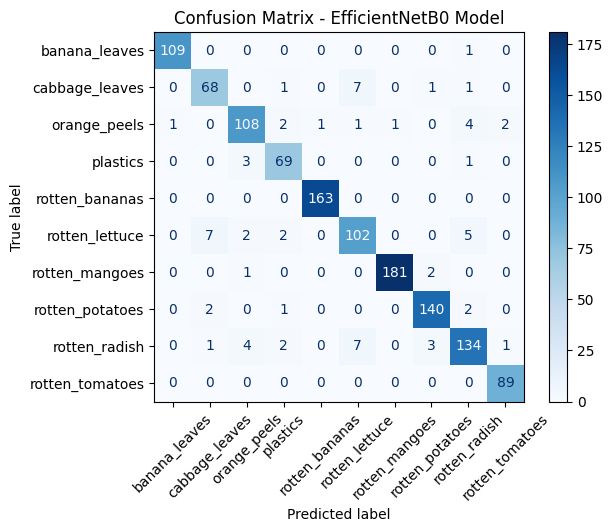


⭐ Overall F1 Score: 0.9438


In [ ]:
# ==========================================================
# 🧾 Evaluate and Report Metrics
# ==========================================================
y_true = test_generator.classes
y_pred_probs = efficientnet_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(test_generator.class_indices.keys())

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score


print("\n📊 Classification Report - EfficientNetB0 Model:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(20, 16))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - EfficientNetB0 Model")
plt.show()

# Compute overall F1 score
overall_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"\n⭐ Overall F1 Score: {overall_f1:.4f}")



<Figure size 2000x1600 with 0 Axes>

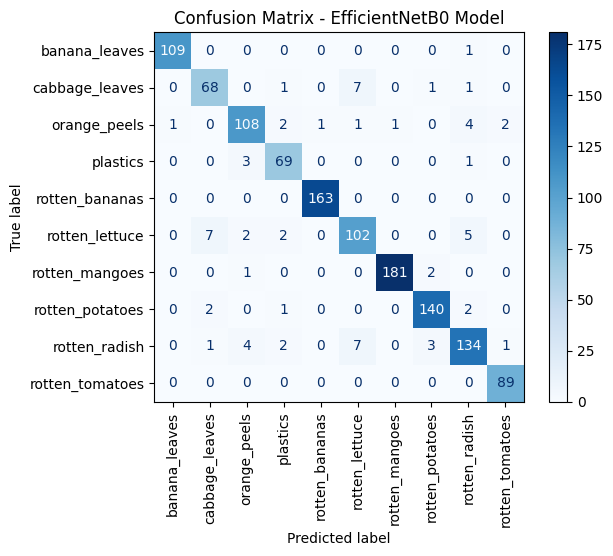

In [ ]:
plt.figure(figsize=(20, 16))
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix - EfficientNetB0 Model")
plt.show()

In [ ]:
efficientnet_model.save(MODEL_SAVE_PATH)
print(f"💾 Model saved successfully at: {MODEL_SAVE_PATH}")

💾 Model saved successfully at: /content/drive/MyDrive/Capstone/models/efficientnetb0_finetuned_waste_classifier_extended.h5


### ResNet

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [ ]:
# ===============================
# 1. Directory for preprocessed data
# ===============================
PREPROCESSED_DATA_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended/"

# ===============================
# 2. Create Image Data Generators
# ===============================
train_datagen_resnet = ImageDataGenerator(rescale=1./255)
val_datagen_resnet = ImageDataGenerator(rescale=1./255)
test_datagen_resnet = ImageDataGenerator(rescale=1./255)

# ===============================
# 3. Load Data from Directories
# ===============================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_generator_resnet = train_datagen_resnet.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator_resnet = val_datagen_resnet.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator_resnet = test_datagen_resnet.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("✅ Preprocessed image generators created successfully.")


Found 5748 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.
✅ Preprocessed image generators created successfully.


In [ ]:
# ===============================
# 4. Define ResNet50 Model
# ===============================
'''def build_resnet50_model(input_shape, num_classes):
    # Load ResNet50 base model with pre-trained ImageNet weights
    resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze base model layers (transfer learning)
    for layer in resnet_base.layers:
        layer.trainable = False

    # Build the model
    model = models.Sequential()
    model.add(resnet_base)
    model.add(layers.GlobalAveragePooling2D())  # Better than Flatten for CNN feature maps
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model'''

def build_resnet50_model(input_shape, num_classes):
    resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze all layers first
    for layer in resnet_base.layers:
        layer.trainable = False

    # Unfreeze the last 15 layers for fine-tuning
    for layer in resnet_base.layers[-15:]:
        layer.trainable = True

    # Build the model
    model = models.Sequential([
        resnet_base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



In [ ]:
# ===============================
# 5. Build and Compile the Model
# ===============================
input_shape = IMG_SIZE + (3,)
num_classes = train_generator_resnet.num_classes

resnet50_model = build_resnet50_model(input_shape, num_classes)

resnet50_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet50_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 6,574,602 (25.08 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [ ]:
# ===============================
# 6. Train the Model
# ===============================
EPOCHS = 10

history_resnet50 = resnet50_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.2974 - loss: 2.0130 - val_accuracy: 0.2459 - val_loss: 2.6012
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - accuracy: 0.4635 - loss: 1.5225 - val_accuracy: 0.4732 - val_loss: 1.8212
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.5220 - loss: 1.3545 - val_accuracy: 0.3174 - val_loss: 5.6409
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 29s 161ms/step - accuracy: 0.5648 - loss: 1.2349 - val_accuracy: 0.4992 - val_loss: 1.5011
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.5994 - loss: 1.1441 - val_accuracy: 0.5292 - val_loss: 1.3068
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 29s 160ms/step - accuracy: 0.6221 - loss: 1.0771 - val_accuracy: 0.5041 - val_loss: 1.5146
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.6445 - loss: 1.0341 - val_accuracy: 0.5227 - val_loss: 1.4146
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - accuracy: 0.6755 - loss: 0

In [ ]:
# ===============================
# 7. Evaluate on Test Data
# ===============================
test_loss_resnet50, test_acc_resnet50 = resnet50_model.evaluate(test_generator_resnet)
print(f"\n✅ ResNet50 Test Accuracy: {test_acc_resnet50*100:.2f}%")
print(f"✅ ResNet50 Test Loss: {test_loss_resnet50:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.6187 - loss: 1.2922

✅ ResNet50 Test Accuracy: 56.74%
✅ ResNet50 Test Loss: 1.4716


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ===============================
# 8. Evaluate Model with More Metrics
# ===============================

# Get predictions on the test set
test_predictions_resnet50 = resnet50_model.predict(test_generator_resnet)
test_predicted_classes_resnet50 = np.argmax(test_predictions_resnet50, axis=1)

# Get true labels for the test set
test_true_classes_resnet50 = test_generator_resnet.classes
class_labels_resnet50 = list(test_generator_resnet.class_indices.keys())

# Calculate metrics
print("📊 ResNet50 Evaluation Metrics:")
print(classification_report(test_true_classes_resnet50, test_predicted_classes_resnet50, target_names=class_labels_resnet50))

# Calculate Confusion Matrix
conf_matrix_resnet50 = confusion_matrix(test_true_classes_resnet50, test_predicted_classes_resnet50)
print("\nConfusion Matrix:")
print(conf_matrix_resnet50)

39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step
📊 ResNet50 Evaluation Metrics:
                 precision    recall  f1-score   support

  banana_leaves       0.92      0.83      0.87       110
 cabbage_leaves       0.50      0.45      0.47        78
   orange_peels       0.62      0.25      0.36       120
       plastics       0.32      0.49      0.39        73
 rotten_bananas       0.44      0.95      0.61       163
 rotten_lettuce       0.52      0.55      0.53       118
 rotten_mangoes       0.73      0.85      0.78       184
rotten_potatoes       0.77      0.07      0.13       145
  rotten_radish       0.57      0.39      0.46       152
rotten_tomatoes       0.66      0.70      0.68        89

       accuracy                           0.57      1232
      macro avg       0.60      0.55      0.53      1232
   weighted avg       0.62      0.57      0.53      1232


Confusion Matrix:
[[ 91   2   0   0   6   5   1   0   5   0]
 [  0  35   2  11   8  18   0   0   4   0]
 [  4   2  30  10  44

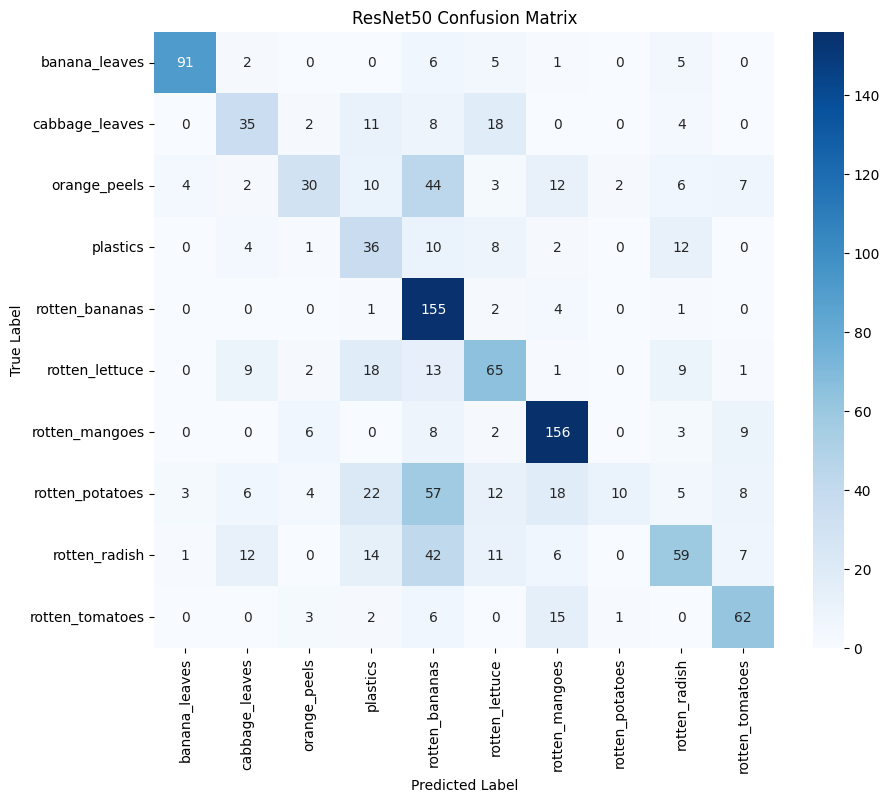

✅ Confusion matrix visualization generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 9. Visualize Confusion Matrix
# ===============================

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_resnet50, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_resnet50, yticklabels=class_labels_resnet50)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet50 Confusion Matrix')
plt.show()

print("✅ Confusion matrix visualization generated successfully.")

### MobileNET

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/Capstone/models/mobilenetv2_finetuned_waste_classifier_extended.h5"

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
def build_mobilenet_model(input_shape, num_classes):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze most layers
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    for layer in base_model.layers[-40:]:
        layer.trainable = True

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

In [ ]:
input_shape = IMG_SIZE + (3,)
num_classes = train_generator.num_classes

mobilenet_model = build_mobilenet_model(input_shape, num_classes)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 2,012,042 (7.68 MB)

 Non-trainable params: 576,448 (2.20 MB)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 4248s 23s/step - accuracy: 0.5790 - loss: 1.3629 - val_accuracy: 0.7808 - val_loss: 0.7836
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.9019 - loss: 0.3433 - val_accuracy: 0.8482 - val_loss: 0.5728
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 28s 155ms/step - accuracy: 0.9609 - loss: 0.1897 - val_accuracy: 0.8701 - val_loss: 0.5230
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.9735 - loss: 0.1370 - val_accuracy: 0.8839 - val_loss: 0.4757
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 28s 155ms/step - accuracy: 0.9817 - loss: 0.1069 - val_accuracy: 0.9026 - val_loss: 0.4241
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 149ms/step - accuracy: 0.9894 - loss: 0.0810 - val_accuracy: 0.9034 - val_loss: 0.4584
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.9940 - loss: 0.0701 - val_accuracy: 0.8929 - val_loss: 0.4801
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.9937 - loss: 0

39/39 ━━━━━━━━━━━━━━━━━━━━ 810s 21s/step

📊 Classification Report - MobileNetV2 Model:
                 precision    recall  f1-score   support

  banana_leaves       1.00      0.97      0.99       110
 cabbage_leaves       0.91      0.79      0.85        78
   orange_peels       0.94      0.86      0.90       120
       plastics       0.92      0.95      0.93        73
 rotten_bananas       1.00      0.96      0.98       163
 rotten_lettuce       0.72      0.91      0.80       118
 rotten_mangoes       0.97      0.96      0.96       184
rotten_potatoes       0.91      0.95      0.93       145
  rotten_radish       0.88      0.86      0.87       152
rotten_tomatoes       0.98      0.96      0.97        89

       accuracy                           0.92      1232
      macro avg       0.92      0.92      0.92      1232
   weighted avg       0.93      0.92      0.92      1232



<Figure size 2000x1600 with 0 Axes>

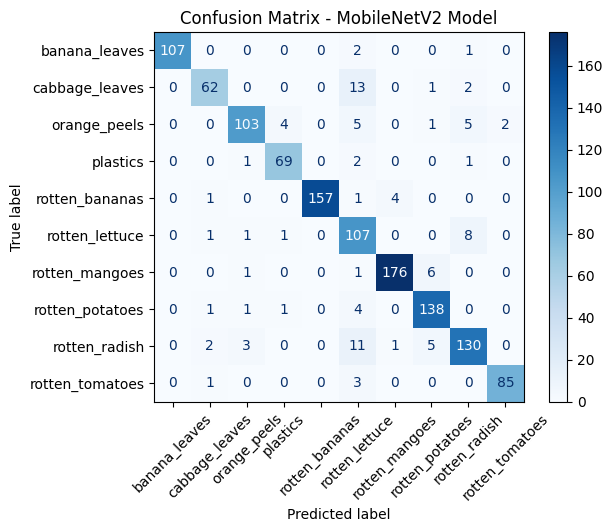


⭐ Overall F1 Score: 0.9217


In [ ]:
y_true = test_generator.classes
y_pred_probs = mobilenet_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(test_generator.class_indices.keys())

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

print("\n📊 Classification Report - MobileNetV2 Model:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(20, 16))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - MobileNetV2 Model")
plt.show()

overall_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"\n⭐ Overall F1 Score: {overall_f1:.4f}")

In [ ]:
# ==========================================================
# 💾 Save Trained MobileNetV2 Model
# ==========================================================
mobilenet_model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved successfully at: {MODEL_SAVE_PATH}")

✅ Model saved successfully at: /content/drive/MyDrive/Capstone/models/mobilenetv2_finetuned_waste_classifier_extended.h5


### Mobile evaluation metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Capstone/models/mobilenetv2_finetuned_waste_classifier_extended.h5"
TEST_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
model = load_model(MODEL_PATH)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,492 (9.87 MB)

 Trainable params: 2,012,042 (7.68 MB)

 Non-trainable params: 576,448 (2.20 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
num_classes = len(class_names)

Found 1232 images belonging to 10 classes.


In [ ]:
y_true = test_generator.classes
y_prob = model.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


39/39 ━━━━━━━━━━━━━━━━━━━━ 292s 8s/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

cm = confusion_matrix(y_true, y_pred)

# Specificity (macro-averaged)
specificity_list = []
for i in range(num_classes):
    tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity_list.append(tn / (tn + fp))
specificity = np.mean(specificity_list)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Error Rate     : {error_rate:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"Specificity    : {specificity:.4f}")
print(f"F1-Score       : {f1:.4f}")


Accuracy       : 0.9205
Error Rate     : 0.0795
Precision      : 0.9263
Recall         : 0.9205
Specificity    : 0.9911
F1-Score       : 0.9217


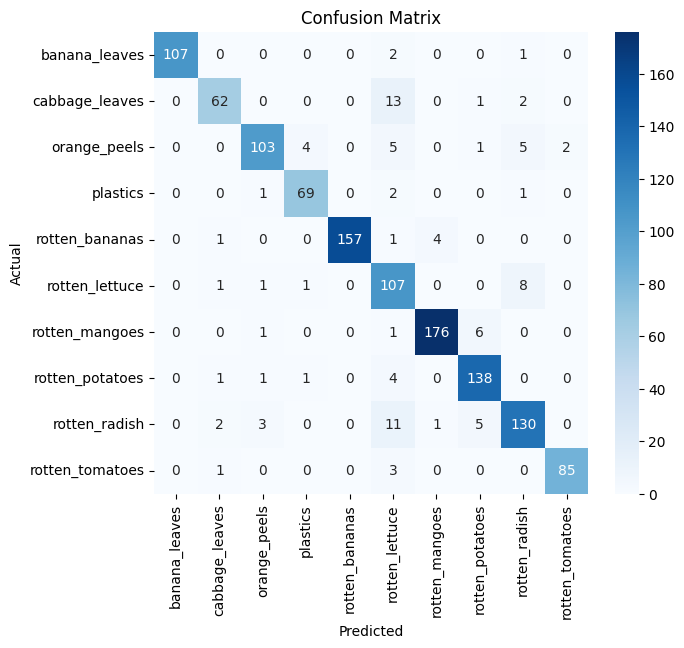

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize

%matplotlib inline


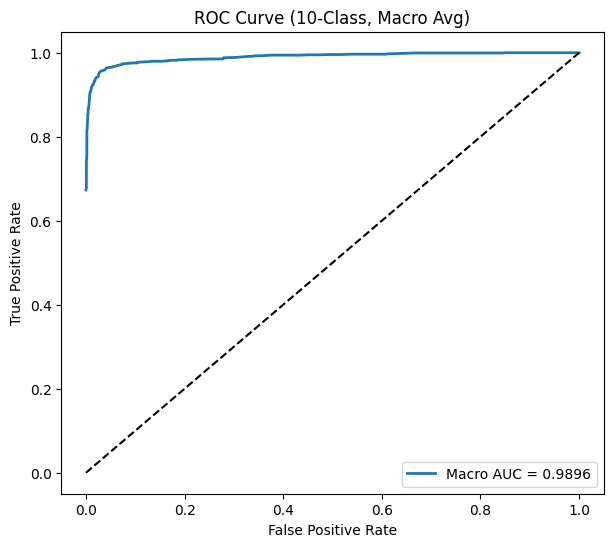

In [ ]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(7,6))
plt.plot(all_fpr, mean_tpr, label=f"Macro AUC = {macro_auc:.4f}", linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (10-Class, Macro Avg)")
plt.legend()
plt.show()


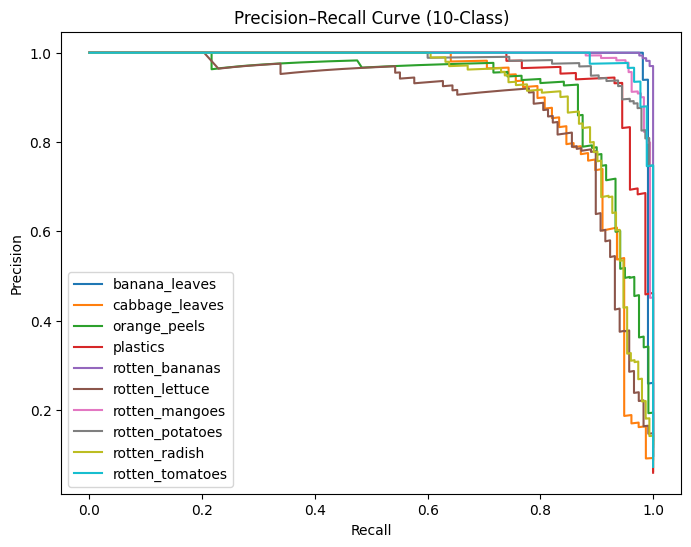

In [ ]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    precision_vals, recall_vals, _ = precision_recall_curve(
        y_true_bin[:, i], y_prob[:, i]
    )
    plt.plot(recall_vals, precision_vals, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (10-Class)")
plt.legend()
plt.show()


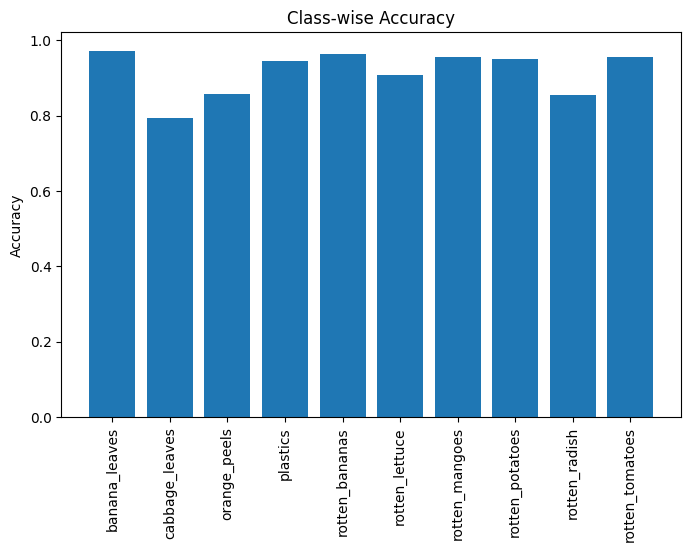

In [ ]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8,5))
plt.bar(class_names, class_accuracy)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.xticks(rotation=90)
plt.show()


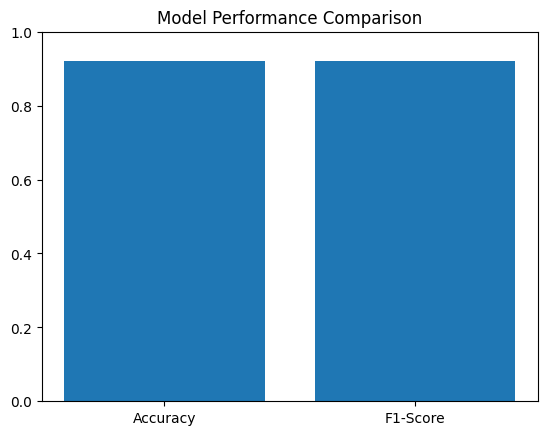

In [ ]:
metrics = ["Accuracy", "F1-Score"]
values = [accuracy, f1]

plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.show()


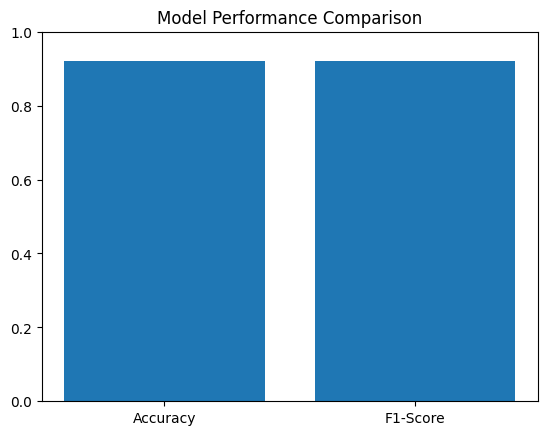

In [ ]:
metrics = ["Accuracy", "F1-Score"]
values = [accuracy, f1]

plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.show()


##

### DenseNET

In [ ]:
# ==========================================================
# ⚡ Fine-Tuned DenseNet121 for Waste Classification
# ==========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [ ]:
# ==========================================================
# 📁 Paths and Parameters
# ==========================================================
PREPROCESSED_DATA_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Capstone/models/densenet121_finetuned_waste_classifier_extended.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
# ==========================================================
# 📦 Data Generators (DenseNet preprocessing)
# ==========================================================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(PREPROCESSED_DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 5748 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.


In [ ]:
# ==========================================================
# 🧠 DenseNet Model Builder
# ==========================================================
def build_densenet_model(input_shape, num_classes):
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze most layers, fine-tune last 60
    for layer in base_model.layers[:-60]:
        layer.trainable = False
    for layer in base_model.layers[-60:]:
        layer.trainable = True

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(
        512,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model


In [ ]:
# ==========================================================
# 🏗️ Build Model
# ==========================================================
input_shape = IMG_SIZE + (3,)
num_classes = train_generator.num_classes

densenet_model = build_densenet_model(input_shape, num_classes)

# ==========================================================
# 🧩 Compile
# ==========================================================
densenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

densenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,567,434 (28.87 MB)

 Trainable params: 1,781,002 (6.79 MB)

 Non-trainable params: 5,786,432 (22.07 MB)

In [ ]:
# ==========================================================
# 🚀 Train
# ==========================================================
history_dense = densenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 2526s 14s/step - accuracy: 0.4854 - loss: 1.5961 - val_accuracy: 0.8758 - val_loss: 0.4433
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 512ms/step - accuracy: 0.8379 - loss: 0.5650 - val_accuracy: 0.9058 - val_loss: 0.3389
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 93s 514ms/step - accuracy: 0.8936 - loss: 0.4013 - val_accuracy: 0.9245 - val_loss: 0.2905
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 511ms/step - accuracy: 0.9181 - loss: 0.3103 - val_accuracy: 0.9253 - val_loss: 0.2765
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 512ms/step - accuracy: 0.9336 - loss: 0.2587 - val_accuracy: 0.9229 - val_loss: 0.2904
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 92s 514ms/step - accuracy: 0.9401 - loss: 0.2289 - val_accuracy: 0.9286 - val_loss: 0.2617
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 93s 516ms/step - accuracy: 0.9494 - loss: 0.1939 - val_accuracy: 0.9383 - val_loss: 0.2765
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 93s 515ms/step - accuracy: 0.9644 - loss: 0

In [ ]:
# ==========================================================
# 💾 Save Model
# ==========================================================
densenet_model.save(MODEL_SAVE_PATH)


In [ ]:
# ==========================================================
# 🧾 Evaluate & Metrics
# ==========================================================
y_true = test_generator.classes
y_pred_probs = densenet_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

print("\n📊 Classification Report - DenseNet121 Model:")
print(classification_report(y_true, y_pred, target_names=class_names))

39/39 ━━━━━━━━━━━━━━━━━━━━ 426s 11s/step

📊 Classification Report - DenseNet121 Model:
                 precision    recall  f1-score   support

  banana_leaves       0.99      0.99      0.99       110
 cabbage_leaves       0.85      0.96      0.90        78
   orange_peels       0.91      0.90      0.90       120
       plastics       0.87      0.99      0.92        73
 rotten_bananas       0.99      1.00      1.00       163
 rotten_lettuce       0.89      0.81      0.85       118
 rotten_mangoes       1.00      0.99      0.99       184
rotten_potatoes       0.95      0.97      0.96       145
  rotten_radish       0.91      0.84      0.88       152
rotten_tomatoes       0.98      0.98      0.98        89

       accuracy                           0.94      1232
      macro avg       0.93      0.94      0.94      1232
   weighted avg       0.94      0.94      0.94      1232



<Figure size 2000x1600 with 0 Axes>

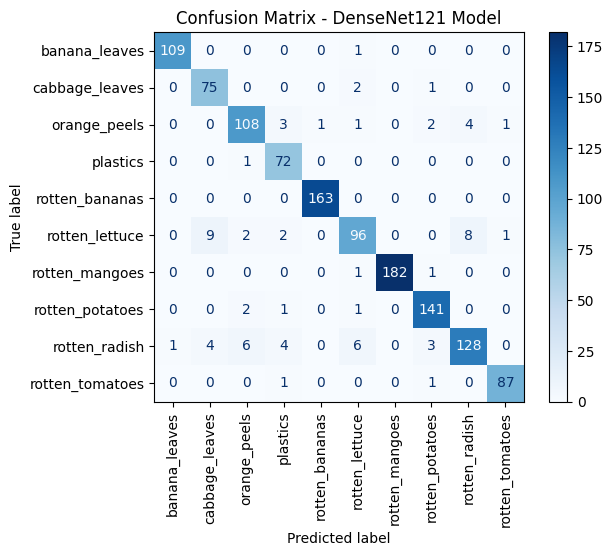


⭐ Overall F1 Score: 0.9419


In [ ]:
# ==========================================================
# 📉 Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix - DenseNet121 Model")
plt.show()

# ==========================================================
# ⭐ Overall F1 Score
# ==========================================================
overall_f1 = f1_score(y_true, y_pred, average='weighted')
print(f"\n⭐ Overall F1 Score: {overall_f1:.4f}")

### Metrics for Densenet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
error_rate = 1 - accuracy

print(f"Accuracy     : {accuracy:.4f}")
print(f"Error Rate   : {error_rate:.4f}")


Accuracy     : 0.9424
Error Rate   : 0.0576


In [ ]:
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-Score     : {f1:.4f}")


Precision    : 0.9430
Recall       : 0.9424
F1-Score     : 0.9419


In [ ]:
cm = confusion_matrix(y_true, y_pred)

specificities = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    specificity = tn / (tn + fp)
    specificities.append(specificity)

specificity_macro = np.mean(specificities)
print(f"Specificity  : {specificity_macro:.4f}")


Specificity  : 0.9937


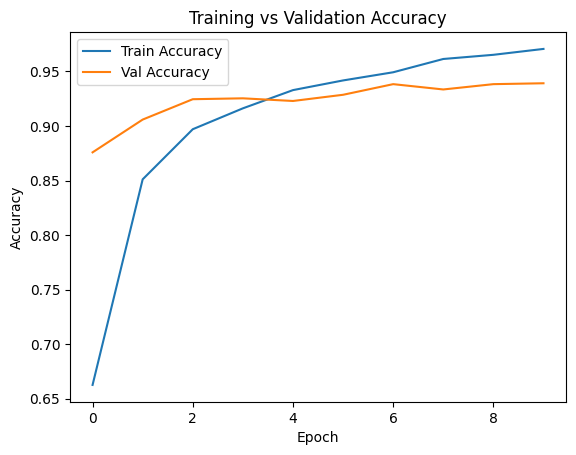

In [ ]:
plt.plot(history_dense.history['accuracy'], label='Train Accuracy')
plt.plot(history_dense.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


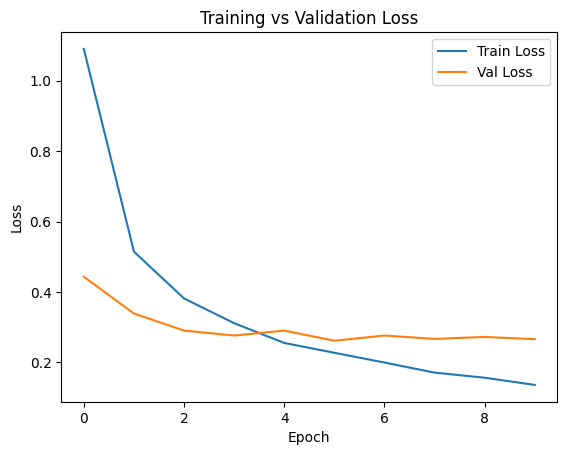

In [ ]:
plt.plot(history_dense.history['loss'], label='Train Loss')
plt.plot(history_dense.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


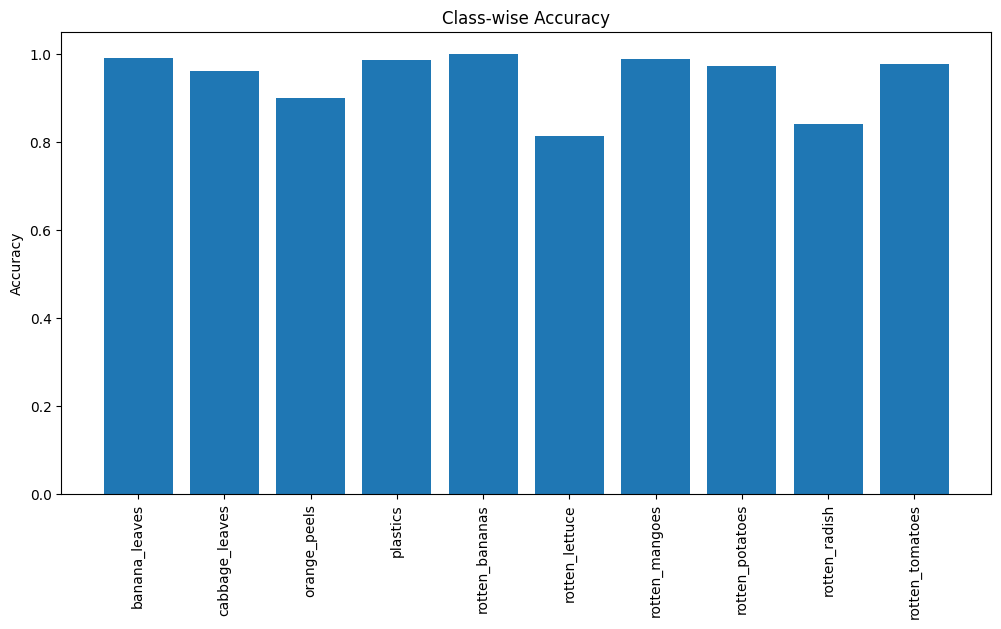

In [ ]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 6))
plt.bar(class_names, class_accuracy)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy")
plt.show()


In [ ]:
from sklearn.preprocessing import label_binarize

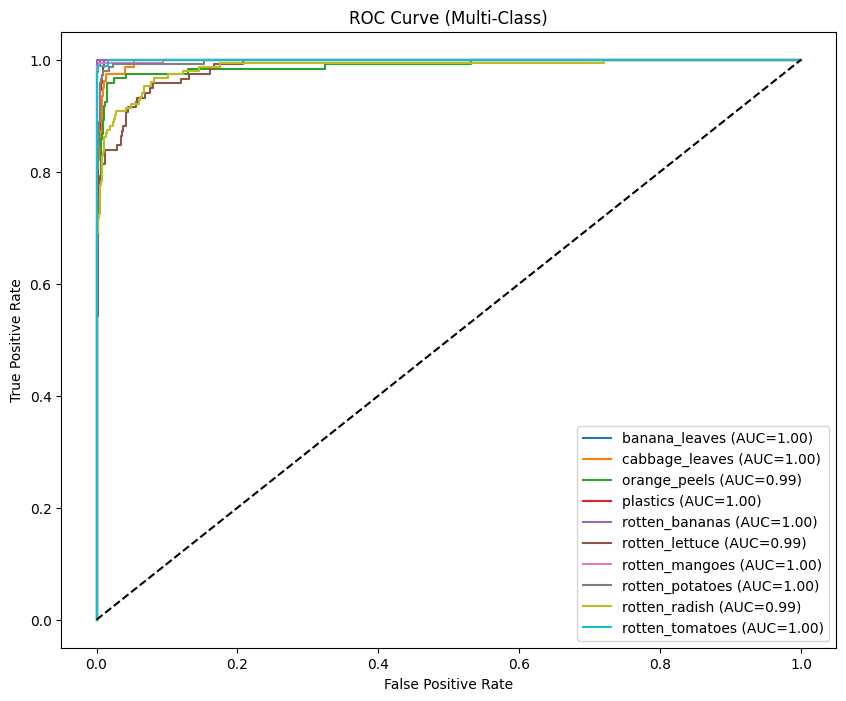

In [ ]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(10, 8))
auc_scores = []

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
    auc_scores.append(auc)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()


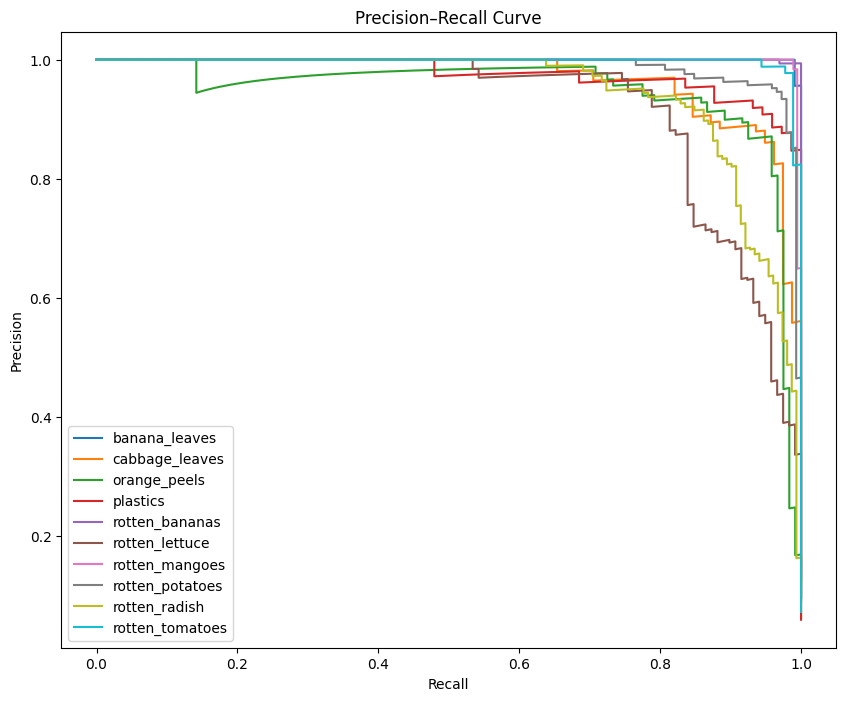

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    precision_c, recall_c, _ = precision_recall_curve(
        y_true_bin[:, i], y_pred_probs[:, i]
    )
    plt.plot(recall_c, precision_c, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()


In [ ]:
import numpy as np

# Save training history
history_path = "/content/drive/MyDrive/Capstone/train_history/densenet_history.npy"
np.save(history_path, history_dense.history)


## EfficientNET B2

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
import pickle


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/Capstone/preprocessed_images_extended/train"
VAL_DIR   = "/content/drive/MyDrive/Capstone/preprocessed_images_extended/val"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Capstone/models/efficientnet_b2_extended.h5"
HISTORY_SAVE_PATH = "/content/drive/MyDrive/Capstone/models/efficientnet_b2_extended_history.pkl"

IMG_SIZE = (260, 260)   # EfficientNet-B2 default
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 10

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 5748 images belonging to 10 classes.
Found 1232 images belonging to 10 classes.


In [ ]:
base_model = EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable =  False  # Transfer learning stage

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,137,475 (31.04 MB)

 Trainable params: 366,090 (1.40 MB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,137,475 (31.04 MB)

 Trainable params: 366,090 (1.40 MB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 4872s 27s/step - accuracy: 0.1322 - loss: 3.6429 - val_accuracy: 0.3101 - val_loss: 2.3952
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 119s 659ms/step - accuracy: 0.2584 - loss: 2.9145 - val_accuracy: 0.4789 - val_loss: 1.9694
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 115s 640ms/step - accuracy: 0.3909 - loss: 2.3567 - val_accuracy: 0.5812 - val_loss: 1.6662
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 119s 659ms/step - accuracy: 0.4700 - loss: 2.1081 - val_accuracy: 0.6558 - val_loss: 1.4612
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 116s 642ms/step - accuracy: 0.5250 - loss: 1.9085 - val_accuracy: 0.6997 - val_loss: 1.3199
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 117s 650ms/step - accuracy: 0.5704 - loss: 1.7353 - val_accuracy: 0.7378 - val_loss: 1.2146
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 116s 643ms/step - accuracy: 0.6187 - loss: 1.6051 - val_accuracy: 0.7687 - val_loss: 1.1390
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 115s 640ms/step - accuracy: 0.6520 - 

In [ ]:
with open(HISTORY_SAVE_PATH, "wb") as f:
    pickle.dump(history.history, f)

print("✅ Training history saved!")

✅ Training history saved!


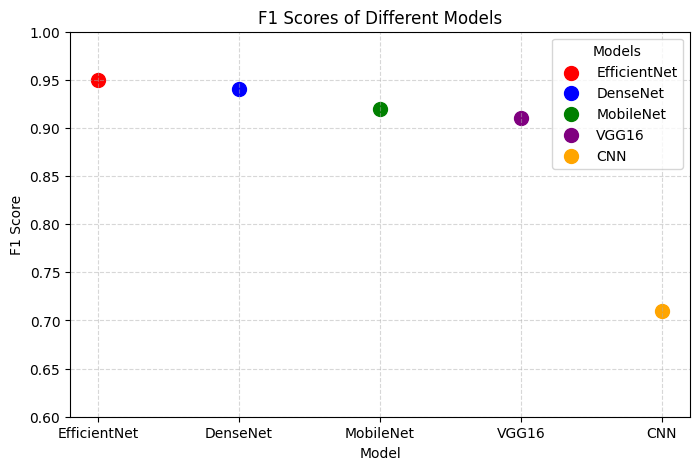

In [ ]:
import matplotlib.pyplot as plt

# Data
models = ['EfficientNet','DenseNet', 'MobileNet','VGG16', 'CNN']
f1_scores = [0.95, 0.94, 0.92, 0.91, 0.71]

# Assign a unique color to each model
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Create scatter plot
plt.figure(figsize=(8, 5))
for i in range(len(models)):
    plt.scatter(models[i], f1_scores[i], color=colors[i], s=100, label=models[i])

# Labels and title
plt.title('F1 Scores of Different Models')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.ylim(0.60, 1.0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Models')

# Show plot
plt.show()


In [ ]:
!find /content/drive/MyDrive/Capstone/preprocessed_images_extended -type f | grep -Ei '\.(jpg|jpeg|png|gif|webp|bmp)$' | wc -l

8212


In [ ]:
!!find /content/drive/MyDrive/Capstone/preprocessed_images_extended/ -type f | grep -Ei '\.(jpg|jpeg|png|gif|webp|bmp)$' | wc -l